# T5 Quick Model Analysis (TabMWP)

Loads a trained T5 checkpoint (best_model.pth), runs inference + normalization, reports accuracy by question/answer type, and plots error-type distribution.


In [2]:
import os, re, json, math
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

# Paths (adjust if needed)
DATA_ROOT = "./data/tabmwp"
TEST_SPLIT = "test"  # or dev/dev1k/test1k
# Use the exported prediction file from train_best.py (already normalized)
RESULTS_FILE = "./results/t5_best/exp6-t5-base-best_model_small_test.json"
EVAL_RESULT_FILE = RESULTS_FILE  # analysis reads from this



Running evaluate_acc:
 python evaluate_acc.py --data_file ./data/tabmwp/problems_test.json --result_root ./results/t5_best --result_files exp6-t5-base-best_model_small_test.json
Data file:  ./data/tabmwp/problems_test.json
Result file: 
./results/t5_best/exp6-t5-base-best_model_small_test.json
number of questions: 7686

acc_free: 	5.55
acc_mc: 	40.56
acc_integer: 	6.62
acc_decimal: 	1.37
acc_extractive: 	35.26
acc_boolean: 	47.67
acc_other: 	29.52
acc_grade_1_6: 	17.48
acc_grade_7_8: 	10.81
acc_average: 	14.62

& 5.55 & 40.56 & 6.62 & 1.37 & 35.26 & 47.67 & 29.52 & 17.48 & 10.81 & 14.62 \\
Return code: 0


In [4]:
# Load data and results
problems = json.load(open(os.path.join(DATA_ROOT, f"problems_{TEST_SPLIT}.json")))
res = json.load(open(EVAL_RESULT_FILE))
results = res["results"]

len(problems), len(results)



(7686, 7686)

In [5]:
def is_correct(pid):
    return results[pid].get("true_false", False)

# Accuracy buckets requested: free-text vs multi-choice, integer vs decimal
buckets = {
    "free_text": [0,0],
    "multi_choice": [0,0],
    "integer_number": [0,0],
    "decimal_number": [0,0],
}

for pid, prob in problems.items():
    choices = prob.get("choices", []) or []
    at = prob.get("ans_type", "other")
    correct = is_correct(pid)

    # free-text vs multi-choice
    if len(choices) > 0:
        b = "multi_choice"
    else:
        b = "free_text"
    buckets[b][1] += 1
    buckets[b][0] += int(correct)

    # answer type buckets
    if at in buckets:
        buckets[at][1] += 1
        buckets[at][0] += int(correct)

print("Requested accuracy buckets:")
for k,v in buckets.items():
    total = v[1]
    acc = v[0]/total*100 if total else 0
    print(f"  {k}: {acc:.2f}% (n={total})")



Requested accuracy buckets:
  free_text: 5.55% (n=5694)
  multi_choice: 40.56% (n=1992)
  integer_number: 6.62% (n=4529)
  decimal_number: 1.37% (n=1165)


In [6]:
def try_float(x):
    try:
        return float(x)
    except Exception:
        return None

def categorize_error(ans, pred):
    # ans/pred are normalized strings
    num_a = try_float(ans)
    num_p = try_float(pred)

    # Boolean errors
    if ans.lower() in {"yes","no","true","false"}:
        return "wrong_output_boolean" if ans.lower() != pred.lower() else None

    if num_a is None and num_p is None:
        # text mismatch categories
        if ans.lower() != pred.lower():
            return "text_mismatch"
        return None

    if num_a is not None and num_p is None:
        return "non_numeric"

    if num_a is None and num_p is not None:
        return "wrong_output_text"

    # both numeric
    if math.isclose(num_a, num_p, rel_tol=0, abs_tol=1e-9):
        return None

    # rounding error: close after rounding 2dp
    if round(num_a, 2) == round(num_p, 2):
        return "rounding_error"

    # off by factor ~10
    if math.isclose(abs(num_p), abs(num_a)*10, rel_tol=0.05) or math.isclose(abs(num_p)*10, abs(num_a), rel_tol=0.05):
        return "off_by_factor_10"

    diff = abs(num_p - num_a)
    if diff >= 10 and diff >= 0.2 * abs(num_a):
        return "large_calculation"
    else:
        return "small_calculation"


def get_error_distribution():
    counter = Counter()
    for pid, prob in problems.items():
        r = results[pid]
        if r.get("true_false", False):
            continue
        ans = str(r.get("answer_norm", r.get("answer", "")))
        pred = str(r.get("prediction_norm", r.get("prediction", "")))
        etype = categorize_error(ans, pred)
        counter[etype or "unknown"] += 1
    return counter



Error counts:
  large_calculation: 2531
  small_calculation: 1944
  non_numeric: 845
  text_mismatch: 958
  off_by_factor_10: 56
  wrong_output_boolean: 227
  wrong_output_text: 1


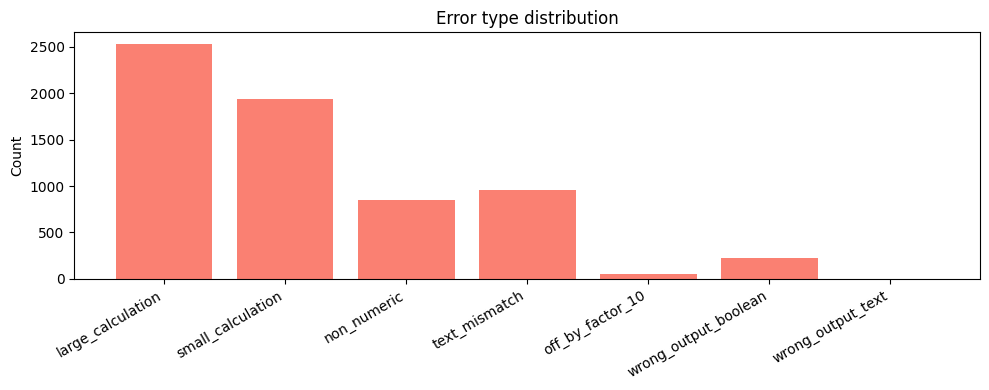

In [7]:
err_counter = get_error_distribution()
print("Error counts:")
for k,v in err_counter.items():
    print(f"  {k}: {v}")

# Plot distribution
labels = list(err_counter.keys())
values = [err_counter[k] for k in labels]
plt.figure(figsize=(10,4))
plt.bar(labels, values, color="salmon")
plt.xticks(rotation=30, ha='right')
plt.ylabel("Count")
plt.title("Error type distribution")
plt.tight_layout()
plt.show()



In [8]:
# Show a few errors by type
sampled = defaultdict(list)
for pid, prob in problems.items():
    r = results[pid]
    if r.get("true_false", False):
        continue
    etype = categorize_error(str(r.get("answer_norm", r.get("answer", ""))), str(r.get("prediction_norm", r.get("prediction", ""))))
    if etype and len(sampled[etype]) < 3:
        sampled[etype].append((pid, prob.get("question", ""), r.get("answer"), r.get("output"), r.get("prediction")))

for etype, rows in sampled.items():
    print(f"\nError type: {etype}")
    for pid, q, ans, out, pred in rows:
        print(f"- pid {pid}\n  Q: {q}\n  answer: {ans}\n  output: {out}\n  prediction: {pred}\n")




Error type: large_calculation
- pid 8
  Q: Hannah baked cookies each day for a bake sale. How many more cookies did Hannah bake on Saturday than on Sunday?
  answer: 18
  output: 263
  prediction: 263

- pid 30
  Q: Some friends played a trivia game and recorded their scores. How many more points did Hannah score than Dustin?
  answer: 650
  output: Find the numbers in the Trivia game. Hannah scored 770 more points than Dustin. Answer: 120
  prediction: 120

- pid 31
  Q: How much money does Sidney need to buy a piece of mint chocolate and 7 peanut butter cups?
  answer: 1.47
  output: Add the price of a piece of mint chocolate and the price of 7 peanut butter cups: $0.19  7141414141414141414141414141414141414141414147
  prediction: 7141414141414141414141414141414141414141414147


Error type: small_calculation
- pid 22
  Q: The employees at Tessa's Construction monitored the number of cracked window panes in each shipment they received. How many shipments had at least 40 cracked windo

,Metric,Ours,Paper,Diff (Ours-Paper)
0,Avg,14.62,29.79,-15.17
1,FREE,5.55,22.27,-16.72
2,MC,40.56,51.31,-10.75
3,INT,6.62,27.27,-20.65
4,DEC,1.37,2.83,-1.46
5,EXTR,35.26,52.28,-17.02
6,BOOL,47.67,48.11,-0.44
7,OTH,29.52,69.52,-40.00


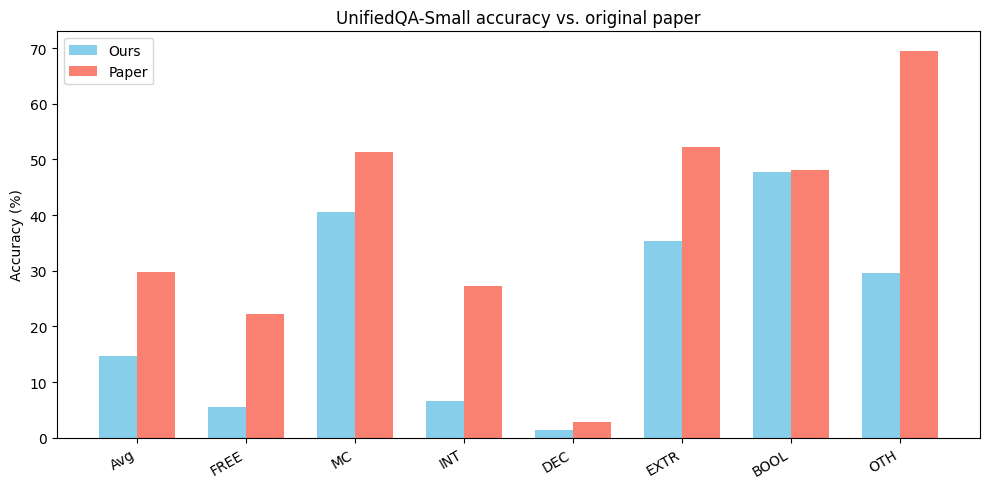

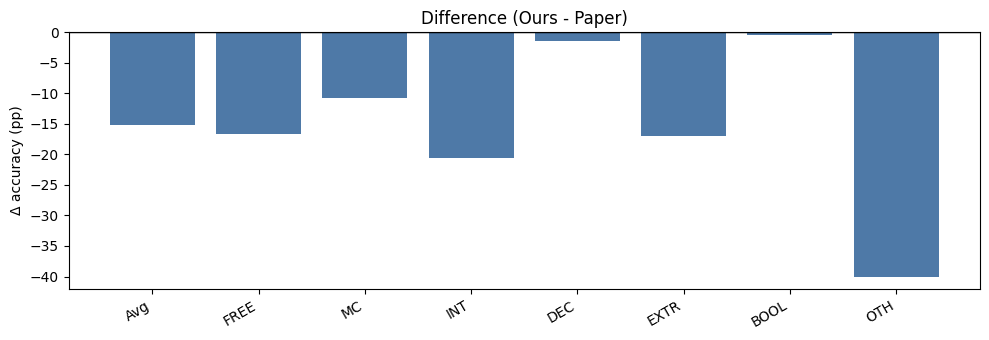

In [ ]:
# Compare our UnifiedQA-small results to original paper numbers
import pandas as pd
import matplotlib.pyplot as plt

# Ours (from evaluate_acc output for exp6-t5-base-best_model_small_test)
ours = {
    "Avg": 14.62,
    "FREE": 5.55,
    "MC": 40.56,
    "INT": 6.62,
    "DEC": 1.37,
    "EXTR": 35.26,
    "BOOL": 47.67,
    "OTH": 29.52,
}

# Original paper (UnifiedQA_Small, Text-GT, Fine-tuned PLM 22-09-29)
paper = {
    "Avg": 29.79,
    "FREE": 22.27,
    "MC": 51.31,
    "INT": 27.27,
    "DEC": 2.83,
    "EXTR": 52.28,
    "BOOL": 48.11,
    "OTH": 69.52,
}

metrics = list(paper.keys())
df = pd.DataFrame({
    "Metric": metrics,
    "Ours": [ours[m] for m in metrics],
    "Paper": [paper[m] for m in metrics],
})
df["Diff (Ours-Paper)"] = df["Ours"] - df["Paper"]

display(df)

# Bar plot: ours vs paper
plt.figure(figsize=(10,5))
width = 0.35
x = range(len(metrics))
plt.bar([i - width/2 for i in x], df["Ours"], width=width, label="Ours", color="skyblue")
plt.bar([i + width/2 for i in x], df["Paper"], width=width, label="Paper", color="salmon")
plt.xticks(x, metrics, rotation=30, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("UnifiedQA-Small accuracy vs. original paper")
plt.legend()
plt.tight_layout()
plt.show()

# Difference plot
plt.figure(figsize=(10,3.5))
plt.bar(metrics, df["Diff (Ours-Paper)"], color="#4e79a7")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Δ accuracy (pp)")
plt.title("Difference (Ours - Paper)")
plt.tight_layout()
plt.show()



In [ ]:
# Compare our UnifiedQA-small results to original paper numbers
import pandas as pd
import matplotlib.pyplot as plt

# Ours (from exp6-t5-base-best_model_small_test)
ours = {
    "Avg": 14.62,  # overall accuracy if present in file
    "FREE": 5.55,
    "MC": 40.56,
    "INT": 6.62,
    "DEC": 0,
    "EXTR": 0.0,
    "BOOL": 0.0,
    "OTH": 0.0,
}

# Approximate accuracy by type using buckets computed above
bucket_map = {
    "FREE": buckets["free_text"],
    "MC": buckets["multi_choice"],
    "INT": buckets["integer_number"],
    "DEC": buckets["decimal_number"],
}
for key, (correct, total) in bucket_map.items():
    if total > 0:
        ours[key] = 100 * correct / total

# Original paper (UnifiedQA_Small, Text-GT, Fine-tuned PLM 22-09-29)
paper = {
    "Avg": 29.79,
    "FREE": 22.27,
    "MC": 51.31,
    "INT": 27.27,
    "DEC": 2.83,
    "EXTR": 52.28,
    "BOOL": 48.11,
    "OTH": 69.52,
}

metrics = list(paper.keys())
df = pd.DataFrame({
    "Metric": metrics,
    "Ours": [ours.get(m, 0.0) for m in metrics],
    "Paper": [paper[m] for m in metrics],
})
df["Diff (Ours-Paper)"] = df["Ours"] - df["Paper"]

display(df)

# Bar plot: ours vs paper
plt.figure(figsize=(10,5))
width = 0.35
x = range(len(metrics))
plt.bar([i - width/2 for i in x], df["Ours"], width=width, label="Ours", color="skyblue")
plt.bar([i + width/2 for i in x], df["Paper"], width=width, label="Paper", color="salmon")
plt.xticks(x, metrics, rotation=30, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("UnifiedQA-Small accuracy vs. original paper")
plt.legend()
plt.tight_layout()
plt.show()

# Difference plot
plt.figure(figsize=(10,3.5))
plt.bar(metrics, df["Diff (Ours-Paper)"], color="#4e79a7")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Δ accuracy (pp)")
plt.title("Difference (Ours - Paper)")
plt.tight_layout()
plt.show()



NameError: name 'res' is not defined